# **Proyecto 1**
## Competencia de Modelación 
### Deep Learning y sistemas inteligentes
Melisa Dayana Mendizabal Meléndez 23778

# **Análisis exploratorio**
## Carga del dataset

Con esta vista inicial del set de datos se puede intuir que este contiene información sobre los detalles de casas y el precio de las mismas.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('train.csv')
print(df.head())

     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   255          20       RL         70.0     8400   Pave   NaN      Reg   
1  1067          60       RL         59.0     7837   Pave   NaN      IR1   
2   639          30       RL         67.0     8777   Pave   NaN      Reg   
3   800          50       RL         60.0     7200   Pave   NaN      Reg   
4   381          50       RL         50.0     5000   Pave  Pave      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
2         Lvl    AllPub  ...        0    NaN  MnPrv         NaN       0   
3         Lvl    AllPub  ...        0    NaN  MnPrv         NaN       0   
4         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   

  MoSold YrSold  SaleType  SaleCondition  SalePrice  
0      6   2010        WD         Norm

## Dimensiones del dataset

In [323]:
filas = df.shape[0]
columnas = df.shape[1]
print(f'El dataset cuenta con {columnas} variables y con {filas} filas')


El dataset cuenta con 81 variables y con 1168 filas


## Tipos de variables (numéricas, categóricas, ordinales) y variable objetivo

Existen 80 variables, siendo la variable objetivo SalePrice que se almacena el precio de venta de la casa que se presenta. El resto de las variables muestra condiciones que afectan el precio de la casa como el vecindario, tamaño de las habitaciones, si esta cuenta con piscina y demás.

In [324]:
columnas = df.columns
columnas

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Listado de las variables junto con el tipo de dato que almacena. 

In [325]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

### Separación por tipo de variables

In [326]:
numericas_continuas = df.select_dtypes(include=['float64']).columns.tolist()
numericas_discretas = df.select_dtypes(include=['int64']).columns.tolist()
numericas =  df.select_dtypes(include=['float64','int64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas_continuas ({len(numericas_continuas)}):', numericas_continuas)
print()
print(f'Variables numéricas_discretas ({len(numericas_discretas)}):', numericas_discretas)
print()
print(f'Variables categóricas ({len(categoricas)}):', categoricas)

Variables numéricas_continuas (3): ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

Variables numéricas_discretas (35): ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categóricas (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Cent

## Estadísticas descriptivas
### Resumen de variables numéricas

In [327]:
df.describe(include=('int64', 'float64')).T[['mean','50%','std','min','max']]

,mean,50%,std,min,max
Id,730.904966,732.5,425.369088,1.0,1460.0
MSSubClass,56.849315,50.0,42.531862,20.0,190.0
LotFrontage,70.343849,70.0,24.897021,21.0,313.0
LotArea,10689.642123,9600.0,10759.366198,1300.0,215245.0
OverallQual,6.121575,6.0,1.367619,1.0,10.0
OverallCond,5.584760,5.0,1.116062,1.0,9.0
YearBuilt,1970.965753,1972.0,30.675495,1872.0,2010.0
YearRemodAdd,1984.897260,1994.0,20.733955,1950.0,2010.0
MasVnrArea,103.771945,0.0,173.032238,0.0,1378.0
BsmtFinSF1,446.023973,384.5,459.070977,0.0,5644.0


### Resumen de variables categóricas

In [328]:
df.describe(include='object').T

,count,unique,top,freq
MSZoning,1168,5,RL,924
Street,1168,2,Pave,1164
Alley,74,2,Grvl,44
LotShape,1168,4,Reg,729
LandContour,1168,4,Lvl,1059
Utilities,1168,2,AllPub,1167
LotConfig,1168,5,Inside,822
LandSlope,1168,3,Gtl,1108
Neighborhood,1168,25,NAmes,181
Condition1,1168,9,Norm,1004


### Categorías de variables categóricas

In [329]:
# Categóricas (moda, cuántas categorías únicas, frecuencia de la moda)
resumen_cat = pd.DataFrame({
    'n_categorias': df[categoricas].nunique(),
    'moda': df[categoricas].mode().iloc[0],
    'freq_moda': df[categoricas].apply(lambda x: x.value_counts().iloc[0])
})
resumen_cat.sort_values('n_categorias', ascending=False)

,n_categorias,moda,freq_moda
Neighborhood,25,NAmes,181
Exterior2nd,16,VinylSd,410
Exterior1st,15,VinylSd,420
SaleType,9,WD,1012
Condition1,9,Norm,1004
Condition2,8,Norm,1157
HouseStyle,8,1Story,577
Functional,7,Typ,1084
RoofMatl,7,CompShg,1149
BsmtFinType2,6,Unf,1009


## Identificación y tratamiento de valores nulos, atípicos (outliers) y posibles inconsistencias.

### Valores Nulos


In [330]:

nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
porcentaje = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje (%)': porcentaje})
resumen_nulos

,nulos,porcentaje (%)
PoolQC,1162,99.49
MiscFeature,1122,96.06
Alley,1094,93.66
Fence,935,80.05
MasVnrType,683,58.48
FireplaceQu,547,46.83
LotFrontage,217,18.58
GarageType,64,5.48
GarageYrBlt,64,5.48
GarageFinish,64,5.48


### Tratamiento de valores nulos

In [331]:
df_clean = df.copy()

# Grupo A: NaN significa "no tiene esa característica" rellenar con 'None' o 0
cat_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType',
            'GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond',
            'BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for col in cat_none:
    df_clean[col] = df_clean[col].fillna('None')

num_zero = ['GarageYrBlt','MasVnrArea']
for col in num_zero:
    df_clean[col] = df_clean[col].fillna(0)

# Grupo B: nulo genuino -> imputar con mediana por Neighborhood
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical: 1 solo nulo -> moda
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

print('Nulos restantes:', df_clean.isnull().sum().sum())

Nulos restantes: 0


In [332]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    1168 non-null   float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          1168 non-null   object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

### Valores atípicos

In [333]:
Q1, Q3 = df['SalePrice'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers_price = df[(df['SalePrice'] < lim_inf) | (df['SalePrice'] > lim_sup)]
print(f'Outliers SalePrice (IQR): {len(outliers_price)} ({len(outliers_price)/len(df)*100:.1f}%)')

Outliers SalePrice (IQR): 48 (4.1%)


In [334]:
sospechosos = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
sospechosos[['GrLivArea','SalePrice','OverallQual','YearBuilt']]

,GrLivArea,SalePrice,OverallQual,YearBuilt
365,4676,184750,10,2007
495,5642,160000,10,2008


### Tratamiento de valores atípicos

In [335]:
df_clean = df_clean[~((df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000))]
print('Filas tras remover outliers:', df_clean.shape[0])
print('Filas eliminadas', (filas - df_clean.shape[0]))

Filas tras remover outliers: 1166
Filas eliminadas 2


### Inconsistencias

In [336]:
# Ej: año de remodelación no puede ser anterior al año de construcción
inconsist1 = df[df['YearRemodAdd'] < df['YearBuilt']]
print('YearRemodAdd < YearBuilt:', len(inconsist1))

# Ej: GarageYrBlt no debería ser mayor a YrSold
inconsist2 = df[df['GarageYrBlt'] > df['YrSold']]
print('GarageYrBlt > YrSold:', len(inconsist2))

# Ej: casas con GarageCars=0 pero GarageArea>0 (o viceversa)
inconsist3 = df[(df['GarageCars'] == 0) & (df['GarageArea'] > 0)]
print('GarageCars=0 pero GarageArea>0:', len(inconsist3))

YearRemodAdd < YearBuilt: 0
GarageYrBlt > YrSold: 0
GarageCars=0 pero GarageArea>0: 0


## Visualizaciones
### Distribución de la variable objetivo

c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


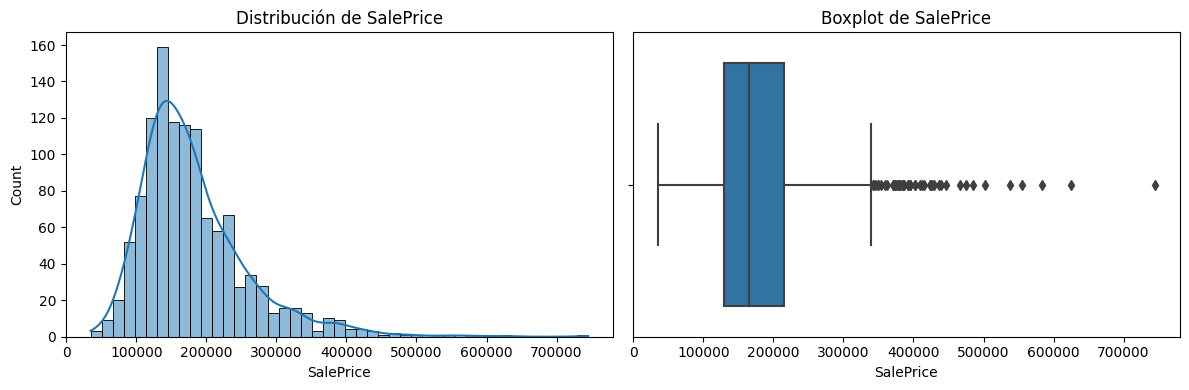

Skewness: 1.743128561420854


In [337]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de SalePrice')

sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title('Boxplot de SalePrice')
plt.tight_layout()
plt.show()

print('Skewness:', df['SalePrice'].skew())

### Correlaciones entre features

In [338]:
corr = df[numericas].corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr.head(15)

SalePrice       1.000000
OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
GarageYrBlt     0.480351
MasVnrArea      0.459123
Fireplaces      0.457549
BsmtFinSF1      0.359460
Name: SalePrice, dtype: float64

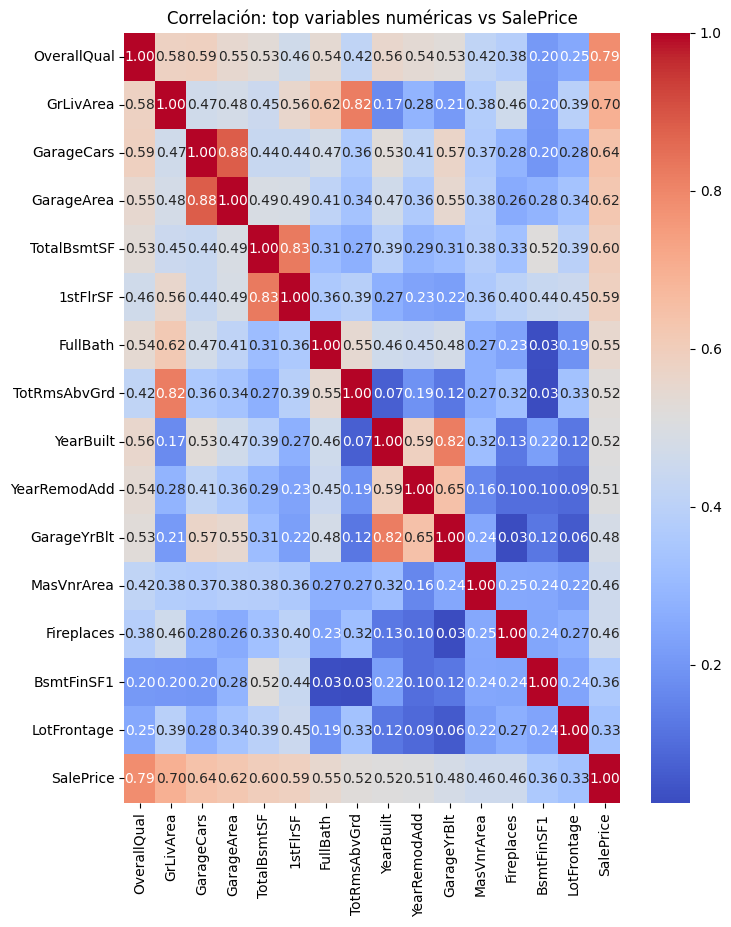

In [339]:
plt.figure(figsize=(8, 10))
top_corr = corr.drop('SalePrice').head(15).index
sns.heatmap(df[list(top_corr) + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación: top variables numéricas vs SalePrice')
plt.show()

### Relación de cada feature con la variable objetivo

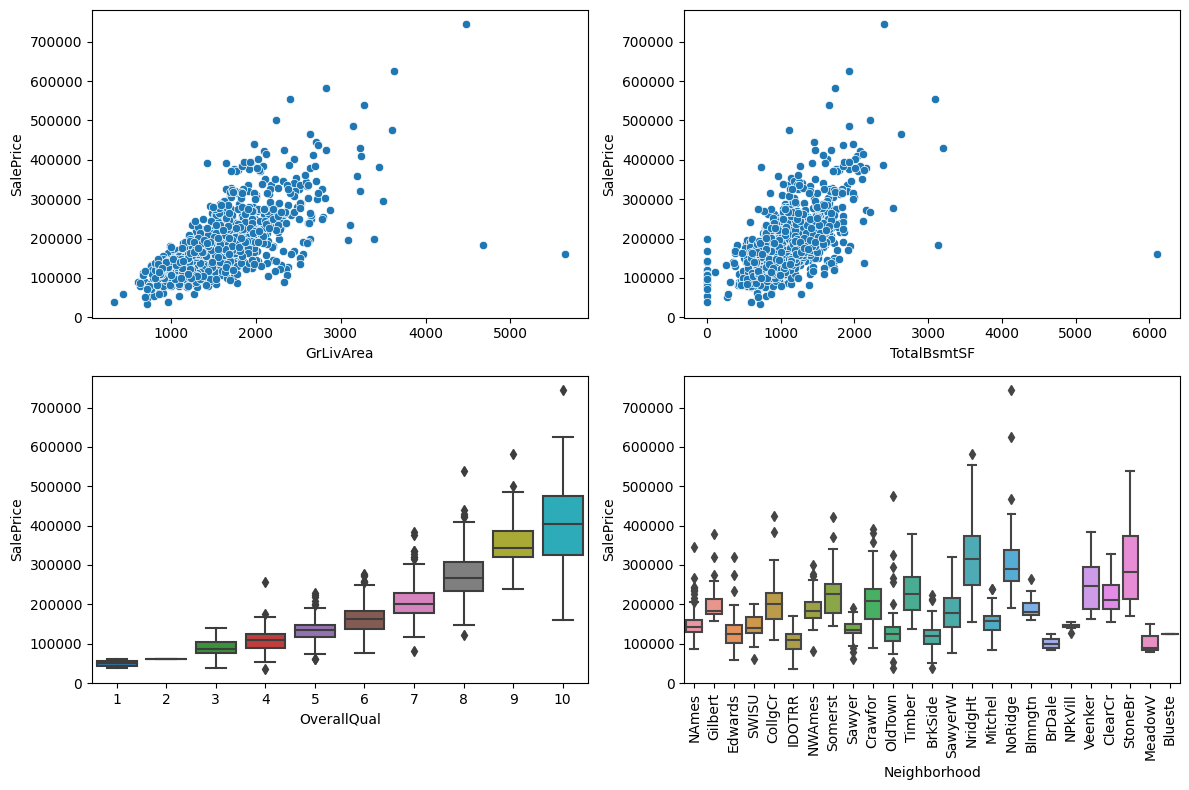

In [340]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0,0])
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df, ax=axes[0,1])
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1,0])
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## Decisiones de preprocesamiento derivadas del EDA

### Encoding

In [341]:
# Encoding ordinal (mapeo manual, orden Po < Fa < TA < Gd < Ex)
mapa_calidad = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

cols_calidad = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

for col in cols_calidad:
    df_clean[col] = df_clean[col].map(mapa_calidad)

In [342]:
# El resto de ordinales con escalas propias (ajusta según lo que tengas)
mapa_bsmt_exposure = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df_clean['BsmtExposure'] = df_clean['BsmtExposure'].map(mapa_bsmt_exposure)

mapa_bsmt_fin = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df_clean['BsmtFinType1'] = df_clean['BsmtFinType1'].map(mapa_bsmt_fin)
df_clean['BsmtFinType2'] = df_clean['BsmtFinType2'].map(mapa_bsmt_fin)

In [ ]:
# One-hot para las nominales restantes
categoricas_nominales_restantes = df_clean.select_dtypes(include='object').columns.tolist()
print('Nominales a codificar:', categoricas_nominales_restantes)

df_encoded = pd.get_dummies(df_clean, columns=categoricas_nominales_restantes, drop_first=True)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Shape tras one-hot:', df_encoded.shape)

Nominales a codificar: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Shape tras one-hot: (1166, 215)


In [344]:
df_encoded.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=215)

# Metodología de desarrollo
## Estrategia de división de datos 

In [ ]:
# Separar X, y ANTES de escalar (para no tocar el target)
ids = df_encoded['Id'].copy()

X = df_encoded.drop(columns=['SalePrice', 'Id'])
y = df_encoded['SalePrice']

### Transformación del target

Se identificó en el análisis exploratorio que SalePrice presenta un sesgo positivo (skewness = 1.74), con una distribución de cola larga hacia la derecha. 
Se decidió aplicar log1p a SalePrice para reducir el sesgo y mejorar la convergencia del MLP.

In [ ]:
y_log = np.log1p(y)

## Estrategia de división de datos

In [ ]:
# Normalización — SOLO fit con train, nunca con val/test
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Split 70/15/15: primero separamos el test (15%), luego dividimos el resto en train/val
X_temp, X_test, y_temp, y_test = train_test_split(X, y_log, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)
# 0.1765 del 85% restante ≈ 15% del total
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

### Normalización
Train para ajustar pesos, val para decidir hiperparámetros y aplicar early stopping durante el desarrollo (evita ver el test), test como evaluación final e insesgada antes de la competencia, simula qué tan bien generalizaría con datos nunca vistos.

In [ ]:
# Normalización — fit SOLO con train
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Preparar los datos para PyTorch


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando:', device)

class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = HousingDataset(X_train_scaled, y_train)
val_ds = HousingDataset(X_val_scaled, y_val)
test_ds = HousingDataset(X_test_scaled, y_test)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

## Técnicas de regularización utilizadas
- Dropout (0.3): apaga aleatoriamente 30% de neuronas en cada paso de entrenamiento, evita que la red dependa demasiado de neuronas específicas (overfitting).
- BatchNorm1d: normaliza las activaciones dentro de la red, estabiliza y acelera el entrenamiento.
- Weight decay: lo agregamos en el optimizador (siguiente paso) — es regularización L2, penaliza pesos muy grandes.
- Early stopping: lo implementamos en el loop de entrenamiento (más abajo) — detiene el entrenamiento si val_loss deja de mejorar, evitando overfitting por sobre-entrenar.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))   # batch normalization
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))  # dropout
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # capa de salida (regresión)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

input_dim = X_train_scaled.shape[1]
model = MLP(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout=0.3).to(device)
print(model)

## Función de pérdida, optimizador, tasa de aprendizaje y demás hiperparámetros

In [ ]:
criterion = nn.MSELoss()  # RMSE = sqrt(MSE), así que entrenamos con MSE y sacamos raíz al reportar

learning_rate = 1e-3
weight_decay = 1e-4  # regularización L2

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Opcional: reduce el learning rate si el val_loss se estanca
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

### Loop de entrenamiento con early stopping

In [ ]:
import numpy as np

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None,
                 max_epochs=200, patience=15):
    best_val_loss = float('inf')
    epochs_sin_mejora = 0
    best_model_state = None
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(max_epochs):
        # --- entrenamiento ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- validación ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)

        # --- early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_sin_mejora = 0
        else:
            epochs_sin_mejora += 1

        if epoch % 10 == 0:
            print(f'Epoch {epoch}: train_RMSE={np.sqrt(train_loss):.4f}, val_RMSE={np.sqrt(val_loss):.4f}')

        if epochs_sin_mejora >= patience:
            print(f'Early stopping en epoch {epoch}')
            break

    model.load_state_dict(best_model_state)  # nos quedamos con el mejor modelo
    return model, history

model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler)